# <b>Ecommerce Data Analysis</b>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv("ecommerce_sales_data.csv")
df

,OrderID,Date,Category,Product,UnitPrice,Quantity,TotalAmount,PaymentMethod,Region,CustomerRating
0,ORD-1001,2023-04-13,Home & Kitchen,Blender,75.19,1,75.19,Credit Card,North America,4
1,ORD-1002,2023-06-29,Home & Kitchen,Coffee Maker,76.09,1,76.09,PayPal,Asia-Pacific,4
2,ORD-1003,2023-04-03,Electronics,Bluetooth Speaker,134.58,3,403.74,Credit Card,Europe,3
3,ORD-1004,2023-01-15,Clothing,Hoodie,41.23,1,41.23,Credit Card,North America,1
4,ORD-1005,2023-04-17,Electronics,Smartwatch,41.75,1,41.75,UPI,North America,4
...,...,...,...,...,...,...,...,...,...,...
215,ORD-1216,2023-04-07,Home & Kitchen,Blender,107.68,1,107.68,PayPal,Latin America,5
216,ORD-1217,2023-05-04,Books,Sci-Fi Paperback,18.55,1,18.55,Credit Card,Europe,5
217,ORD-1218,2023-03-11,Clothing,Cotton T-Shirt,68.38,3,205.14,UPI,Asia-Pacific,5
218,ORD-1219,2023-04-03,Electronics,USB-C Hub,38.83,3,116.49,PayPal,Europe,1


In [3]:
df.head(5)

,OrderID,Date,Category,Product,UnitPrice,Quantity,TotalAmount,PaymentMethod,Region,CustomerRating
0,ORD-1001,2023-04-13,Home & Kitchen,Blender,75.19,1,75.19,Credit Card,North America,4
1,ORD-1002,2023-06-29,Home & Kitchen,Coffee Maker,76.09,1,76.09,PayPal,Asia-Pacific,4
2,ORD-1003,2023-04-03,Electronics,Bluetooth Speaker,134.58,3,403.74,Credit Card,Europe,3
3,ORD-1004,2023-01-15,Clothing,Hoodie,41.23,1,41.23,Credit Card,North America,1
4,ORD-1005,2023-04-17,Electronics,Smartwatch,41.75,1,41.75,UPI,North America,4


In [21]:
grp = df.groupby("Category")["TotalAmount"].sum().sort_values(ascending =False)
grp1 = df.groupby("Category")["Quantity"].sum().sort_values(ascending =False)

# <u> Revenue & quantity analysis</u>

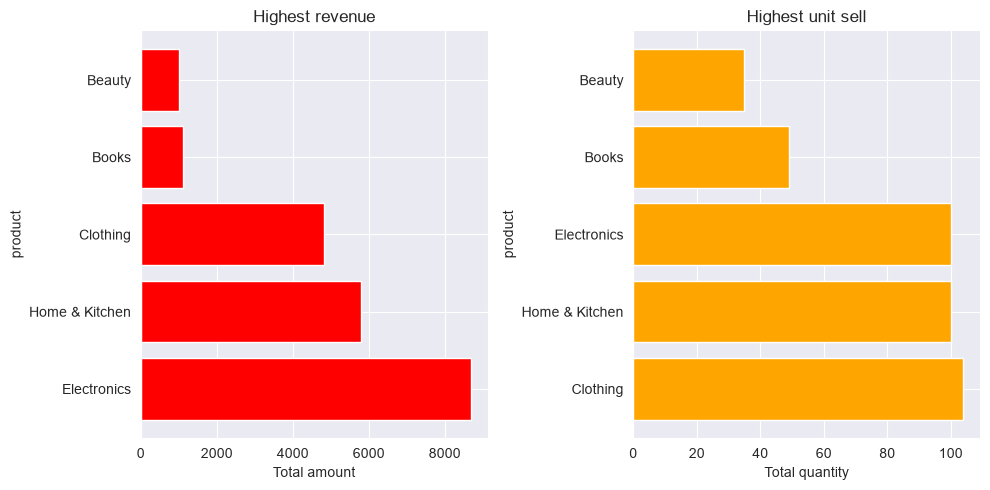

In [85]:
fig, ax = plt.subplots(1,2,figsize=(10,5))

x=grp.index
y=grp.values
ax[0].barh(x,y,color="red")
ax[0].set_title("Highest revenue")
ax[0].set_xlabel("Total amount")
ax[0].set_ylabel("product")

x1=grp1.index
y1=grp1.values
ax[1].barh(x1,y1,color="orange")
ax[1].set_title("Highest unit sell")
ax[1].set_xlabel("Total quantity")
ax[1].set_ylabel("product")


plt.tight_layout()
sns.set_style("darkgrid")
plt.savefig("Revenue_quantity_analysis.png",dpi=300,bbox_inches="tight")
plt.show()

###  Key Insights: Category-Wise Revenue & Quantity
* **Top Revenue Performer:** **Electronics** generated the highest total revenue ($8,690.89), driven mainly by higher unit prices.
* **Volume Leader:** **Clothing** led in total volume with **104 units sold**, closely followed by Electronics and Home & Kitchen (100 units each).
* **Actionable Takeaway:** Focus marketing campaigns on high-margin Electronics, while creating cross-selling bundles for high-volume items like Clothing.

# <u>Month by month sales</u>

In [64]:
df["Date"]=pd.to_datetime(df["Date"])
df["month"]=df["Date"].dt.to_period('M')
monthly_revenue = df.groupby('month')['TotalAmount'].sum().reset_index()
monthly_revenue['month_Str'] = monthly_revenue['month'].dt.strftime('%b %Y')
monthly_revenue

,month,TotalAmount,month_Str
0,2023-01,3128.06,Jan 2023
1,2023-02,3387.53,Feb 2023
2,2023-03,3219.31,Mar 2023
3,2023-04,3768.55,Apr 2023
4,2023-05,5122.58,May 2023
5,2023-06,2802.75,Jun 2023


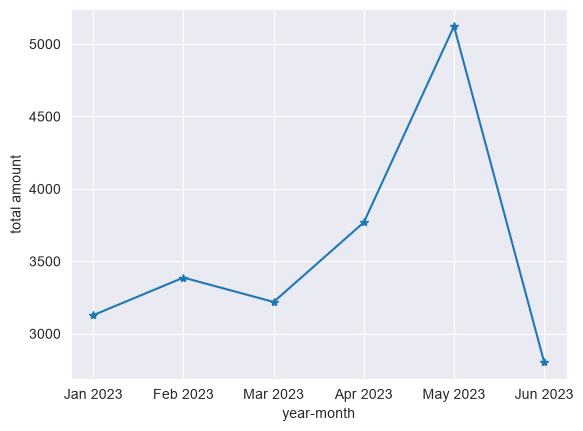

In [86]:
plt.plot(monthly_revenue['month_Str'],monthly_revenue['TotalAmount'],marker="*",)
plt.xlabel("year-month")
plt.ylabel("total amount")
plt.savefig("month.png",dpi=300,bbox_inches="tight")
plt.show()


### Key insights: Monthly revenue trend 
* **Peak revenue month:** May 2023 generate the highest sales peak **5122.58**, showing steady growth from january.
* **Lowest revenue month:** jun 2023 generate the lowest sales.
* **actionable Takeaway:** Analyze May marketing campaigns to replicate strategies in mid-year low periods like June.

# <u>Regional Category Sales Heatmap</u>

In [58]:
matrix = pd.pivot_table(df,index="Region",columns="Category",values="TotalAmount",fill_value=0)
matrix

Category,Beauty,Books,Clothing,Electronics,Home & Kitchen
Region,,,,,
Asia-Pacific,25.735000,33.264286,76.426154,180.856250,101.957500
Europe,64.256667,42.272500,88.976667,160.420556,86.177273
Latin America,45.456667,59.420000,74.082500,115.622857,87.214286
North America,56.785000,27.502727,83.782000,154.222174,120.797200


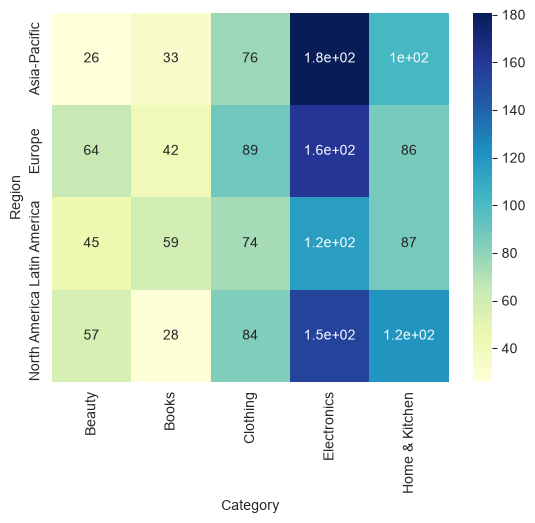

In [87]:
sns.heatmap(data=matrix,annot=True,cmap='YlGnBu')
plt.savefig("Regional_category.png",dpi=300,bbox_inches="tight")
plt.show()

### Key insights:category vs region
* **Top Performing Category:** Electronics leads in every region (180 in Asia-Pacific, **160** in Europe, **150** in North America, and **120** in Latin America).

* **Top Performing Region:** Asia-Pacific recorded the highest sales for Electronics at **180**.

* **Lowest Performing Category:** Books and Beauty categories have significantly low sales (for example, Beauty sales in Asia-Pacific are only **26**, and Books in North America are at **28**).

# <u>Unit Price Distribution & Outliers</u>

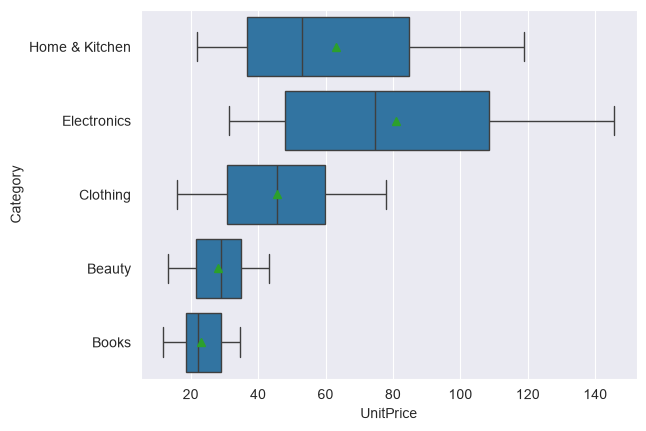

In [88]:
sns.boxplot(y="Category",x="UnitPrice",data =df,showmeans=True)
sns.set_style("darkgrid")
plt.savefig("price_distribution.png",dpi=300,bbox_inches="tight")
plt.show()

### Key insights: Unit price Distribution & outliners
* **Highest price Range:** **Electronics** has a highest unit price and the widest price spread(ranginng from 30 to  over 140), marking it the most premium product category.
* **Lowet price range:** **Books** and **Beauty** has a lowest unit price and also tight distribution around 10 to 35.

# <u>Customer Rating vs Product Price Correlation</u>

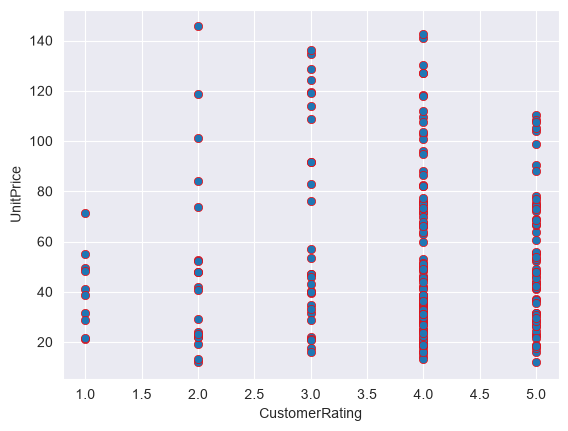

In [89]:
sns.scatterplot(x="CustomerRating",y="UnitPrice",data=df,edgecolor="r")
plt.savefig("Customer_product_correlation.png",dpi=300,bbox_inches="tight")
plt.show()

### Key insights: Customer Rating vs Product Price Correlation
* **Does higher product price (UnitPrice) lead to lower CustomerRating?** 
**--yes,** Higher product price led to lower customer rating.
* At Lowest price have more highest customer rating.

# <u>Regional Payment Method Preferences</u>

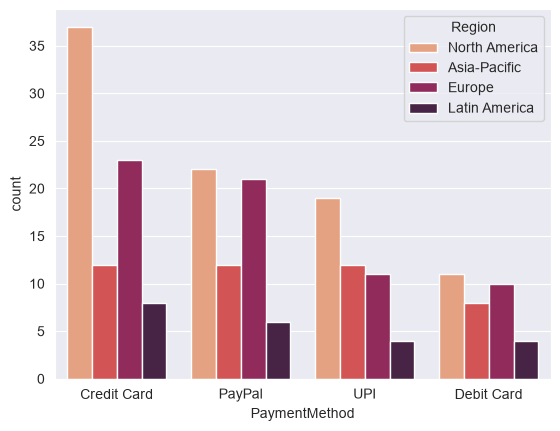

In [90]:
sns.countplot(x="PaymentMethod",data=df,hue="Region",palette="rocket_r")
plt.savefig("Regional_payment_analysis.png",dpi=300,bbox_inches="tight")
plt.show()

### Key Insights: Regional Payment analysis
* **Nort America**, **Asia-Pacific**, **Europe**,**Latin America** most preferred **Credit card**.
* Basicaly all region are most preferred **Credit card** Payment method.